### Setup

In [173]:
%pip install --quiet -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


### Importação

In [174]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import os
import shutil
import string
import random

## Criação dos valores a serem calculados os anagramas

In [175]:
def gerar_palavra(tamanho):
    return ''.join(random.choices(string.ascii_lowercase, k=tamanho))

qtd_values = [10,20,30,40, 50,60,70,80,90]

dados = {
    'palavras': [[gerar_palavra(i) for i in range(1, qtd + 1)] for qtd in qtd_values]
}

### Exibindo Amostragem

In [176]:
print(f"Palavras geradas: {dados['palavras']}")
print(f"Quantidades de dados gerados: {len(dados['palavras'])}", qtd_values)

Palavras geradas: [['d', 'xv', 'omm', 'nlqs', 'wvvvk', 'xrcexi', 'bhrdkpc', 'yyjianhm', 'gdgogclez', 'bgsptgpghr'], ['d', 'bc', 'oaw', 'thhw', 'cybjg', 'jxzjxn', 'loanfmw', 'lxmqugdt', 'zuthqzqqx', 'plujlbpack', 'hyklwcqwmrv', 'uqeqzenvcfrt', 'tliykoyczatpc', 'popxeoejqkedqb', 'nbdciouivvinhhv', 'ftmoueutwydslyjt', 'rbbzwplkwegnqbioj', 'bbxjzmzepqhleqahmg', 'wswfgazrbmabnhottld', 'cixvijapqpaywauswmhj'], ['s', 'am', 'nwm', 'axmm', 'atqth', 'lnlwvb', 'sjzrdcj', 'zqvjzvsv', 'aqddhdzfa', 'iytbzrzbmm', 'dfymdskfryn', 'bqutkdigkcbe', 'nvzzxliynzzrj', 'ihiflecdliguxd', 'aewsmnmapmsxuoq', 'qnxczdzivmthxofj', 'jbhtaajpjnsxaulqw', 'skvgckfnkugtqyyvab', 'mghkfmpgzlzavfcnmwz', 'hibahdertspcxwnxegmz', 'hvnxnxocikjvadiarxvhu', 'jgcajclrwyfscmclzlbomo', 'zkltnztwtuzpaxeelxfdwzh', 'gnuvqzxbukwelhiobkjlcxfi', 'tzypkdhjidsyqqbmkttnhlseh', 'aapbogyjhcsxrfuryijbjffwxe', 'fsubzdungbxbmnyegfptqhricxn', 'lrutgcuyyklubmdeeunpohimytkm', 'dwcmhjlidpwnfivuawroixsdhxlef', 'bvwtzmmbiopcdikstsmyfbsttrxmnw'], ['m',

### Salvando amostragem em txt

In [177]:
paths = []

# Caminho base
base_path = 'files/palavras'
shutil.rmtree('files', ignore_errors=True)

os.makedirs(base_path, exist_ok=True)

for title, values in dados.items():
    for i, value in enumerate(values):
        path = f'files/{title}/{len(value)}_palavras.csv'
        paths.append(path)
        
        os.makedirs(os.path.dirname(path), exist_ok=True)
        
        # Converte as palavras em um DataFrame (uma coluna com cada palavra em uma linha)
        df = pd.DataFrame(value, columns=["Palavra"])
        # Salva o DataFrame no arquivo CSV
        df.to_csv(path, index=False, header=False)
# Exibe os arquivos gerados
        
print(f'Arquivos salvos em {os.path.abspath("files")}')

Arquivos salvos em /home/user/Projetos/Trabalho-2---PAA/files


## Recursivo

In [178]:
%%capture anagrama_results_recursive
for path in paths:
    tamanho = path.split('/')[-1].split('.')[0].split('_')[0]
    args_copy = f"FILE_PATH={path} QTD_WORD={tamanho} QTD_TEST=10 SHOW_RESULT=0"
    !make -B anagrama_recursivo {args_copy}

In [179]:
anagrama_results_recursive.show()

Tempo:0.000005s Memoria:0.49KB Qtd:10
Tempo:0.000008s Memoria:0.85KB Qtd:20
Tempo:0.000012s Memoria:1.31KB Qtd:30
Tempo:0.000016s Memoria:1.62KB Qtd:40
Tempo:0.000021s Memoria:2.16KB Qtd:50
Tempo:0.000026s Memoria:2.63KB Qtd:60
Tempo:0.000029s Memoria:3.03KB Qtd:70
Tempo:0.000036s Memoria:3.42KB Qtd:80
Tempo:0.000039s Memoria:4.00KB Qtd:90


## Dinamico

In [180]:
%%capture anagrama_results_dinamico
for path in paths:
    tamanho = path.split('/')[-1].split('.')[0].split('_')[0]
    args_copy = f"FILE_PATH={path} QTD_WORD={tamanho} QTD_TEST=10 SHOW_RESULT=0"
    !make -B anagrama_dinamico {args_copy}

In [181]:
anagrama_results_dinamico.show()


Tempo:0.000651s Memoria:1.35KB Qtd:10
Tempo:0.000717s Memoria:1.50KB Qtd:20
Tempo:0.000727s Memoria:1.68KB Qtd:30
Tempo:0.000724s Memoria:1.88KB Qtd:40
Tempo:0.000690s Memoria:2.10KB Qtd:50
Tempo:0.000666s Memoria:2.35KB Qtd:60
Tempo:0.000671s Memoria:2.62KB Qtd:70
Tempo:0.000660s Memoria:2.92KB Qtd:80
Tempo:0.000714s Memoria:3.24KB Qtd:90


# Graficos

In [182]:
def formatar_dados(results):
  # Extrai os dados do resultado
  data = []
  lines = results.stdout.split('\n')
  
  for line in lines:
      if line.startswith('Tempo:'):
          parts = line.split()
          tempo = parts[0].split(':')[1][:-1]
          memoria = parts[1].split(':')[1][:-2]
          qtd = parts[2].split(':')[1]
          data.append((tempo, memoria, qtd))
  return pd.DataFrame(data, columns=["Tempo", "Memoria", "Qtd"])


In [188]:
print("\nAnagramas recursivo")
formatado_recusivo = formatar_dados(anagrama_results_recursive)
formatado_recusivo


Anagramas recursivo


,Tempo,Memoria,Qtd
0,0.000005,0.49,10
1,0.000008,0.85,20
2,0.000012,1.31,30
3,0.000016,1.62,40
4,0.000021,2.16,50
5,0.000026,2.63,60
6,0.000029,3.03,70
7,0.000036,3.42,80
8,0.000039,4.00,90


In [189]:
print("\nAnagramas recursivo")
formatado_dinamico = formatar_dados(anagrama_results_dinamico)
formatado_dinamico


Anagramas recursivo


,Tempo,Memoria,Qtd
0,0.000651,1.35,10
1,0.000717,1.50,20
2,0.000727,1.68,30
3,0.000724,1.88,40
4,0.000690,2.10,50
5,0.000666,2.35,60
6,0.000671,2.62,70
7,0.000660,2.92,80
8,0.000714,3.24,90


In [197]:
def gerar_graficos(data):
  # Converte os dados de tempo e memória para float
  data["Tempo"] = data["Tempo"].astype(float)
  data["Memoria"] = data["Memoria"].astype(float)
  data["Qtd"] = data["Qtd"].astype(int)

  # Configura os gráficos lado a lado
  fig, axes = plt.subplots(1, 2, figsize=(14, 6))

  # Gráfico de Tempo
  axes[0].plot(data["Qtd"], data["Tempo"], marker='o', label="Tempo")
  axes[0].set_title("Tempo de Execução")
  axes[0].set_xlabel("Quantidade de Palavras")
  axes[0].set_ylabel("Tempo (s)")
  axes[0].grid(True)
  axes[0].legend()

  # Gráfico de Memória
  axes[1].plot(data["Qtd"], data["Memoria"], marker='o', color='orange', label="Memória")
  axes[1].set_title("Uso de Memória")
  axes[1].set_xlabel("Quantidade de Palavras")
  axes[1].set_ylabel("Memória (KB)")
  axes[1].grid(True)
  axes[1].legend()

  # Exibe os valores reais nos gráficos
  for i, row in data.iterrows():
      axes[0].text(row["Qtd"], row["Tempo"], f"{row['Tempo']}", fontsize=9, ha='right')
      axes[1].text(row["Qtd"], row["Memoria"], f"{row['Memoria']}", fontsize=9, ha='right')

  plt.tight_layout()
  plt.show()

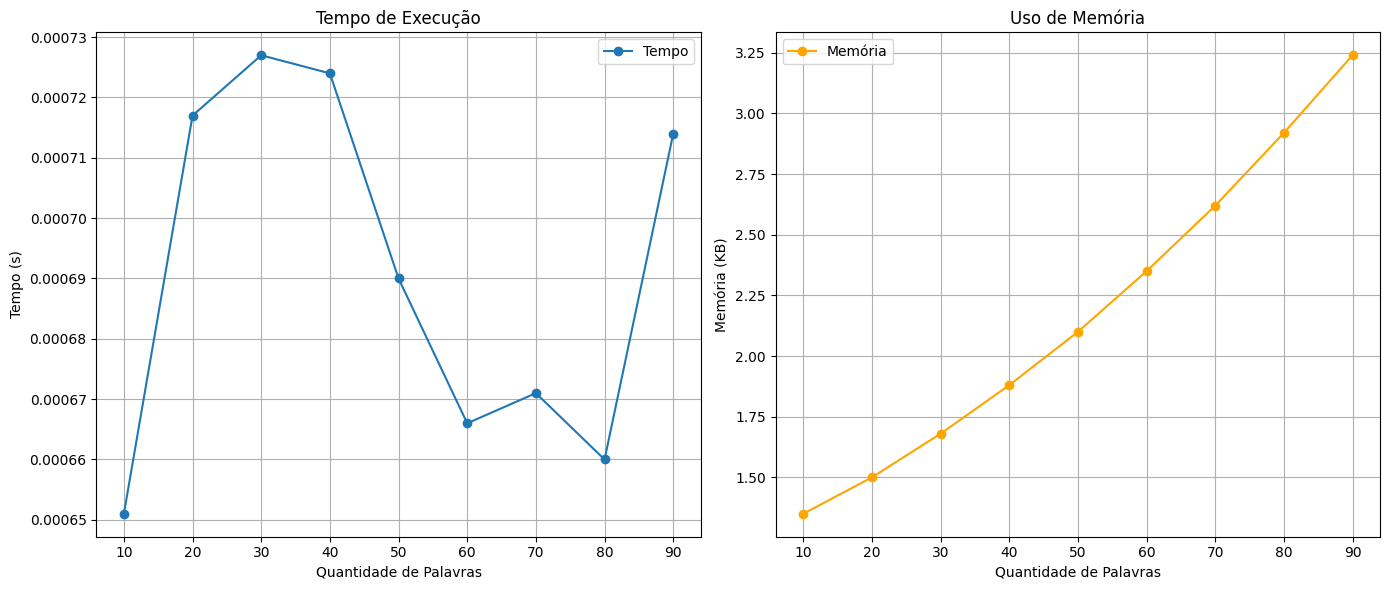

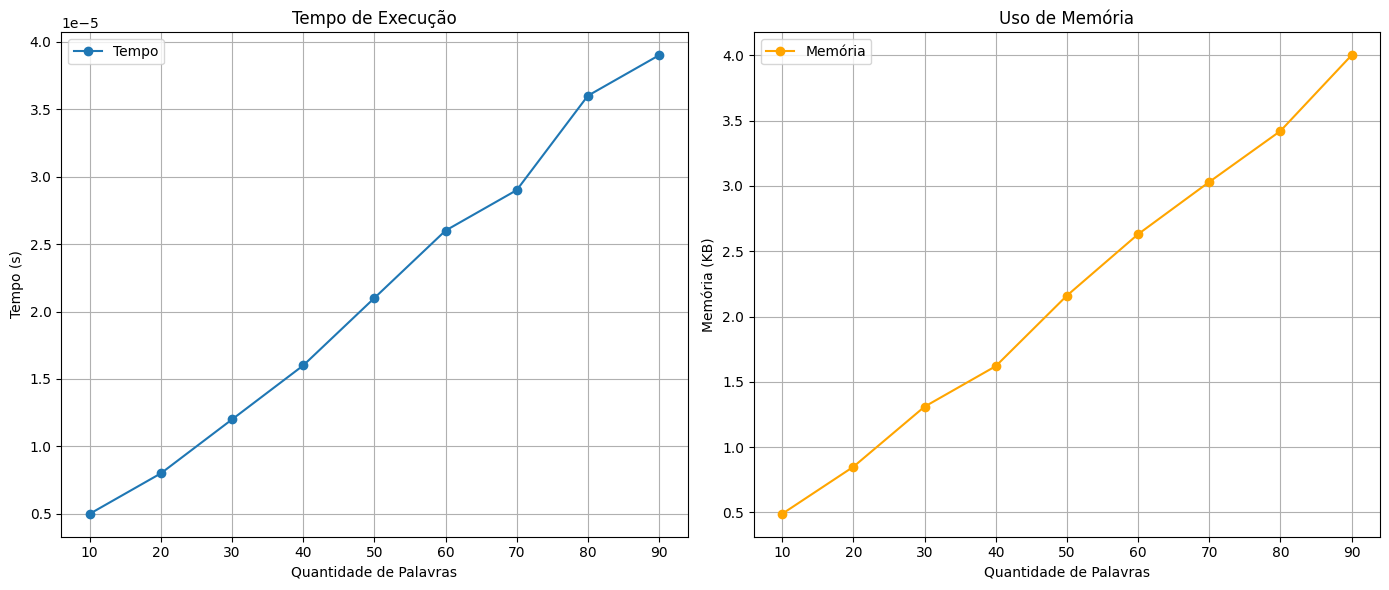

In [195]:
gerar_graficos(formatar_dados(anagrama_results_dinamico))
gerar_graficos(formatar_dados(anagrama_results_recursive))